In [1]:
import sys, os
#print(os.listdir('.'))

print(os.getcwd())
sys.path.append('.')
cwd = os.getcwd()
os.chdir('../..')
import rsnapsim as rsnp
os.chdir(cwd)


import numpy as np
import multiprocessing
import time
import inspect
import matplotlib.patches as patches

c:\Users\willi\Documents\GitHub\rSNAPsim\rsnapsim\interactive_notebooks
eigen instillation found...
['c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
['c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']


In [2]:
  #@title Plotting style
  import matplotlib.pyplot as plt
  from cycler import cycler
  import matplotlib.cm as cm
  from matplotlib.lines import Line2D
  colors = [ '#06d6a0','#ef476f', '#7400b8','#073b4c', '#118ab2',]
  #colors = ['#fa8174', '#b3de69', '#bc82bd','#ccebc4','#ffed6f','#81b1d2']
  font = {'family' : 'sans-serif',
          'weight' : 'bold',
          'size'   : 12}
  plt.rcParams.update({'font.size': 12, 'font.weight':'bold', 'font.family':'sans-serif'  }   )
  plt.rcParams.update({'axes.prop_cycle':cycler(color=colors)})
  plt.rcParams.update({'axes.prop_cycle':cycler(color=colors)})
  plt.rcParams.update({'axes.prop_cycle':cycler(color=colors)})
  plt.rcParams.update({'xtick.major.width'   : 2.8 })
  plt.rcParams.update({'xtick.labelsize'   : 12 })
  plt.rcParams.update({'ytick.major.width'   : 2.8 })
  plt.rcParams.update({'ytick.labelsize'   : 12})
  plt.rcParams.update({'axes.titleweight'   : 'bold'})
  plt.rcParams.update({'axes.titlesize'   : 10})
  plt.rcParams.update({'axes.labelweight'   : 'bold'})
  plt.rcParams.update({'axes.labelsize'   : 12})
  plt.rcParams.update({'axes.linewidth':2.8})
  plt.rcParams.update({'axes.labelpad':8})
  plt.rcParams.update({'axes.titlepad':10})

In [3]:
plasmid = '''AGCUUGCCUUGAGUGCUCAAAGUAGUGUGUGCCCGUCUGUUGUGUGACUCUGGUAACUAGAGAUCCCUCAGACCCUUUUAGUCAGUGUGGAAAAUCUCUAGCAGUGGCGCCCGAACAGGGACUUGAAAGCGAAAGUAAAGCCAGAGGAGAUCUCUCGACGCAGGACUCGGCUUGCUGAAGCGCGCACGGCAAGAGGCGAGGGGCGGCGACUGGUGAGUACGCCAAAAAUUUUGACUAGCGGAGGCUAGAAGGAGAGAGAUGGGUGCGAGAGCGUCGGUAUUAAGCGGGGGAGAAUUAGAUAAAUGGGAAAAAAUUCGGUUAAGGCCAGGGGGAAAGAAACAAUAUAAACUAAAACAUAUAGUAUGGGCAAGCAGGGAGCUAGAACGAUUCGCAGUUAAUCCUGGCCUUUUAGAGACAUCAGAAGGCUGUAGACAAAUACUGGGACAGCUACAACCAUCCCUUCAGACAGGAUCAGAAGAACUUAGAUCAUUAUAUAAUACAAUAGCAGUCCUCUAUUGUGUGCAUCAAAGGAUAGAUGUAAAAGACACCAAGGAAGCCUUAGAUAAGAUAGAGGAAGAGCAAAACAAAAGUAAGAAAAAGGCACAGCAAGCAGCAGCUGACACAGGAAACAACAGCCAGGUCACCACGCGUUCUGGAGGAGAAGAACUUUUGAGCAAGAAUUAUCAUCUUGAGAACGAAGUGGCUCGUCUUAAGAAAGGUUCUGGCAGUGGAGAAGAACUGCUUUCAAAGAAUUACCACCUGGAAAAUGAGGUAGCUAGACUGAAAAAGGGGAGCGGAAGUGGGGAGGAGUUGCUGAGCAAAAAUUAUCAUUUGGAGAACGAAGUAGCACGACUAAAGAAAGGGUCCGGAUCGGGUGAGGAGUUACUCUCGAAAAAUUAUCAUCUCGAAAACGAAGUGGCUCGGCUAAAAAAGGGCAGUGGUUCUGGAGAAGAGCUAUUAUCUAAAAACUACCACCUCGAAAAUGAGGUGGCACGCUUAAAAAAGGGAAGUGGCAGUGGUGAAGAGCUACUAUCCAAGAAUUAUCAUCUUGAGAACGAGGUAGCGCGUUUGAAGAAGGGUUCCGGCUCAGGAGAGGAACUGCUCUCGAAGAACUAUCAUCUUGAAAAUGAGGUCGCUCGAUUAAAAAAGGGAUCGGGCAGUGGUGAGGAACUACUUUCAAAGAAUUACCACCUCGAAAACGAAGUAGCUCGAUUAAAGAAAGGUUCAGGGUCGGGUGAAGAAUUACUGAGUAAAAAUUAUCAUCUGGAAAAUGAGGUAGCGAGACUAAAAAAGGGGAGUGGUUCUGGCGAAGAGUUGCUAUCGAAAAAUUAUCAUCUUGAGAACGAAGUUGCUAGGCUCAAAAAGGGCUCAGGCUCAGGCGAGGAGUUGCUCUCGAAAAACUACCACUUGGAAAAUGAGGUCGCGAGGUUGAAAAAGGGGAGCGGGUCGGGCGAGGAGUUAUUGAGCAAAAACUAUCAUUUAGAGAACGAAGUCGCGCGCUUAAAGAAAGGCUCGGGCUCGGGCGAAGAACUCUUAUCGAAGAACUACCACCUCGAAAAUGAGGUCGCCAGGUUGAAAAAGGGCAGUGGCAGCGGGGAGGAACUCUUGAGCAAGAACUACCACUUGGAGAAUGAGGUCGCGAGAUUGAAGAAAGGGUCGGGGAGCGGCGAGGAAUUGCUCAGCAAGAAUUAUCAUUUGGAGAACGAAGUCGCCAGGCUCAAGAAAGGCUCGGGGUCGGGGGAGGAAUUGUUGAGUAAAAACUACCACUUGGAAAAUGAAGUCGCCAGGCUCAAAAAAGGGAGUGGGAGCGGCGAAGAGUUAUUGAGCAAAAAUUACCACUUGGAGAACGAAGUGGCAAGGCUCAAGAAAGGGAGCGGCAGCGGGGAGGAGCUCUUAUCGAAGAACUACCACUUAGAGAAUGAAGUCGCCCGCUUGAAGAAAGGCUCGGGGAGCGGGGAAGAGCUCUUGAGCAAGAACUACCACUUGGAAAAUGAGGUGGCGCGCUUGAAGAAAGGGAGCGGGAGCGGGGAAGAGUUACUAUCUAAGAAUUAUCAUCUCGAGAACGAGGUGGCUCGACUAAAGAAGGGCUCCGGCAGUGGGGAGGAACUCCUGUCGAAGAACUAUCAUCUUGAAAAUGAGGUUGCAAGACUUAAAAAGGGGUCCGGAUCAGGUGAGGAACUACUCAGUGCUAGCUCGCGUGUCAGCCAAAAUUACCCUAUAGUGCAGAACCUCCAGGGGCAAAUGGUACAUCAGGCCAUAUCACCUAGAACUUUAAAUGCAUGGGUAAAAGUAGUAGAAGAGAAGGCUUUCAGCCCAGAAGUAAUACCCAUGUUUUCAGCAUUAUCAGAAGGAGCCACCCCACAAGAUUUAAAUACCAUGCUAAACACAGUGGGGGGACAUCAAGCAGCCAUGCAAAUGUUAAAAGAGACCAUCAAUGAGGAAGCUGCAGAAUGGGAUAGAUUGCAUCCAGUGCAUGCAGGGCCUAUUGCACCAGGCCAGAUGAGAGAACCAAGGGGAAGUGACAUAGCAGGAACUACUAGUACCCUUCAGGAACAAAUAGGAUGGAUGACACAUAAUCCACCUAUCCCAGUAGGAGAAAUCUAUAAAAGAUGGAUAAUCCUGGGAUUAAAUAAAAUAGUAAGAAUGUAUAGCCCUACCAGCAUUCUGGACAUAAGACAAGGACCAAAGGAACCCUUUAGAGACUAUGUAGACCGAUUCUAUAAAACUCUAAGAGCCGAGCAAGCUUCACAAGAGGUAAAAAAUUGGAUGACAGAAACCUUGUUGGUCCAAAAUGCGAACCCAGAUUGUAAGACUAUUUUAAAAGCAUUGGGACCAGGAGCGACACUAGAAGAAAUGAUGACAGCAUGUCAGGGAGUGGGGGGACCCGGCCAUAAAGCAAGAGUUUUGGCUGAAGCAAUGAGCCAAGUAACAAAUCCAGCUACCAUAAUGAUACAGAAAGGCAAUUUUAGGAACCAAAGAAAGACUGUUAAGUGUUUCAAUUGUGGCAAAGAAGGGCACAUAGCCAAAAAUUGCAGGGCCCCUAGGAAAAAGGGCUGUUGGAAAUGUGGAAAGGAAGGACACCAAAUGAAAGAUUGUACUGAGAGACAGGCUAAUUUUUUAGGGAAGAUCUGGCCUUCCCACAAGGGAAGGCCAGGGAAUUUUCUUCAGAGCAGACCAGAGCCAACAGCCCCACCAGAAGAGAGCUUCAGGUUUGGGGAAGAGACAACAACUCCCUCUCAGAAGCAGGAGCCGAUAGACAAGGAACUGUAUCCUUUAGCUUCCCUCAGAUCACUCUUUGGCAGCGACCCCUCGUCACAAUAAAGAUAGGGGGGCAAUUAAAGGAAGCUCUAUUAGAUACAGGAGCAGAUGAUACAGUAUUAGAAGAAAUGAAUUUGCCAGGAAGAUGGAAACCAAAAAUGAUAGGGGGAAUUGGAGGUUUUAUCAAAGUAAGACAGUAUGAUCAGAUACUCAUAGAAAUCUGCGGACAUAAAGCUAUAGGUACAGUAUUAGUAGGACCUACACCUGUCAACAUAAUUGGAAGAAAUCUGUUGACUCAGAUUGGCUGCACUUUAAAUUUUCCCAUUAGUCCGCGGAUGGAUUACAAGGAUGACGACGAUAAGGGUUCUGGCAGUGGAGAUUACAAAGACGAUGAUGACAAGGGGAGCGGAAGUGGGGACUACAAGGACGACGACGACAAGGGGUCCGGAUCGGGUGACUACAAAGAUGACGAUGAUAAAGGAGGCGGUCAGCUGGACUACAAGGAUCACGACGGAGACUACAAGGACCACGAUAUCGAUUACAAGGAUGACGAUGAUAAGCUUAUUGAGACUGUACCAGUAAAAUUAAAGCCAGGAAUGGAUGGCCCAAAAGUUAAACAAUGGCCAUUGACAGAAGAAAAAAUAAAAGCAUUAGUAGAAAUUUGUACAGAAAUGGAAAAGGAAGGAAAAAUUUCAAAAAUUGGGCCUGAAAAUCCAUACAAUACUCCAGUAUUUGCCAUAAAGAAAAAAGACAGUACUAAAUGGAGAAAAUUAGUAGAUUUCAGAGAACUUAAUAAGAGAACUCAAGAUUUCUGGGAAGUUCAAUUAGGAAUACCACAUCCUGCAGGGUUAAAACAGAAAAAAUCAGUAACAGUACUGGAUGUGGGCGAUGCAUAUUUUUCAGUUCCCUUAGAUAAAGACUUCAGGAAGUAUACUGCAUUUACCAUACCUAGUAUAAACAAUGAGACACCAGGGAUUAGAUAUCAGUACAAUGUGCUUCCACAGGGAUGGAAAGGAUCACCAGCAAUAUUCCAGUGUAGCAUGACAAAAAUCUUAGAGCCUUUUAGAAAACAAAAUCCAGACAUAGUCAUCUAUCAAUACAUGGAUGAUUUGUAUGUAGGAUCUGACUUAGAAAUAGGGCAGCAUAGAACAAAAAUAGAGGAACUGAGACAACAUCUGUUGAGGUGGGGAUUUACCACACCAGACAAAAAACAUCAGAAAGAACCUCCAUUCCUUUGGAUGGGUUAUGAACUCCAUCCUGAUAAAUGGACAGUACAGCCUAUAGUGCUGCCAGAAAAGGACAGCUGGACUGUCAAUGACAUACAGAAAUUAGUGGGAAAAUUGAAUUGGGCAAGUCAGAUUUAUGCAGGGAUUAAAGUAAGGCAAUUAUGUAAACUUCUUAGGGGAACCAAAGCACUAACAGAAGUAGUACCACUAACAGAAGAAGCAGAGCUAGAACUGGCAGAAAACAGGGAGAUUCUAAAAGAACCGGUACAUGGAGUGUAUUAUGACCCAUCAAAAGACUUAAUAGCAGAAAUACAGAAGCAGGGGCAAGGCCAAUGGACAUAUCAAAUUUAUCAAGAGCCAUUUAAAAAUCUGAAAACAGGAAAAUAUGCAAGAAUGAAGGGUGCCCACACUAAUGAUGUGAAACAAUUAACAGAGGCAGUACAAAAAAUAGCCACAGAAAGCAUAGUAAUAUGGGGAAAGACUCCUAAAUUUAAAUUACCCAUACAAAAGGAAACAUGGGAAGCAUGGUGGACAGAGUAUUGGCAAGCCACCUGGAUUCCUGAGUGGGAGUUUGUCAAUACCCCUCCCUUAGUGAAGUUAUGGUACCAGUUAGAGAAAGAACCCAUAAUAGGAGCAGAAACUUUCUAUGUAGAUGGGGCAGCCAAUAGGGAAACUAAAUUAGGAAAAGCAGGAUAUGUAACUGACAGAGGAAGACAAAAAGUUGUCCCCCUAACGGACACAACAAAUCAGAAGACUGAGUUACAAGCAAUUCAUCUAGCUUUGCAGGAUUCGGGAUUAGAAGUAAACAUAGUGACAGACUCACAAUAUGCAUUGGGAAUCAUUCAAGCACAACCAGAUAAGAGUGAAUCAGAGUUAGUCAGUCAAAUAAUAGAGCAGUUAAUAAAAAAGGAAAAAGUCUACCUGGCAUGGGUACCAGCACACAAAGGAAUUGGAGGAAAUGAACAAGUAGAUGGGUUGGUCAGUGCUGGAAUCAGGAAAGUACUAUUUUUAGAUGGAAUAGAUAAGGCCCAAGAAGAACAUGAGAAAUAUCACAGUAAUUGGAGAGCAAUGGCUAGUGAUUUUAACCUACCACCUGUAGUAGCAAAAGAAAUAGUAGCCAGCUGUGAUAAAUGUCAGCUAAAAGGGGAAGCCAUGCAUGGACAAGUAGACUGUAGCCCAGGAAUAUGGCAGCUAGAUUGUACACAUUUAGAAGGAAAAGUUAUCUUGGUAGCAGUUCAUGUAGCCAGUGGAUAUAUAGAAGCAGAAGUAAUUCCAGCAGAGACAGGGCAAGAAACAGCAUACUUCCUCUUAAAAUUAGCAGGAAGAUGGCCAGUAAAAACAGUACAUACAGACAAUGGCAGCAAUUUCACCAGUACUACAGUUAAGGCCGCCUGUUGGUGGGCGGGGAUCAAGCAGGAAUUUGGCAUUCCCUACAAUCCCCAAAGUCAAGGAGUAAUAGAAUCUAUGAAUAAAGAAUUAAAGAAAAUUAUAGGACAGGUAAGAGAUCAGGCUGAACAUCUUAAGACAGCAGUACAAAUGGCAGUAUUCAUCCACAAUUUUAAAAGAAAAGGGGGGAUUGGGGGGUACAGUGCAGGGGAAAGAAUAGUAGACAUAAUAGCAACAGACAUACAAACUAAAGAAUUACAAAAACAAAUUACAAAAAUUCAAAAUUUUCGGGUUUAUUACAGGGACAGCAGAGAUCCAGUUUGGAAAGGACCAGCAAAGCUCCUCUGGAAAGGUGAAGGGGCAGUAGUAAUACAAGAUAAUAGUGACAUAAAAGUAGUGCCAAGAAGAAAAGCAAAGAUCAUCAGGGAUUAUGGAAAACAGAUGGCAGGUGAUGAUUGUGUGGCAAGUAGACAGGAUGAGGAUUAACACAUGGAAAAGAUUAGUAAAACACCAUAUGUAUAUUUCAAGGAAAGCUAAGGACUGGUUUUAUAGACAUCACUAUGAAAGUACUAAUCCAAAAAUAAGUUCAGAAGUACACAUCCCACUAGGGGAUGCUAAAUUAGUAAUAACAACAUAUUGGGGUCUGCAUACAGGAGAAAGAGACUGGCAUUUGGGUCAGGGAGUCUCCAUAGAAUGGAGGAAAAAGAGAUAUAGCACACAAGUAGACCCUGACCUAGCAGACCAACUAAUUCAUCUGCACUAUUUUGAUUGUUUUUCAGAAUCUGCUAUAAGAAAUACCAUAUUAGGACGUAUAGUUAGUCCUAGGUGUGAAUAUCAAGCAGGACAUAACAAGGUAGGAUCUCUACAGUACUUGGCACUAGCAGCAUUAAUAAAACCAAAACAGAUAAAGCCACCUUUGCCUAGUGUUAGGAAACUGACAGAGGACAGAUGGAACAAGCCCCAGAAGACCAAGGGCCACAGAGGGAGCCAUACAAUGAAUGGACACUAGAGCUUUUAGAGGAACUUAAGAGUGAAGCUGUUAGACAUUUUCCUAGGAUAUGGCUCCAUAACUUAGGACAACAUAUCUAUGAAACUUACGGGGAUACUUGGGCAGGAGUGGAAGCCAUAAUAAGAAUUCUGCAACAACUGCUGUUUAUCCAUUUCAGAAUUGGGUGUCGACAUAGCAGAAUAGGCGUUACUCGACAGAGGAGAGCAAGAAAUGGAGCCAGUAGAUCCUAGACUAGAGCCCUGGAAGCAUCCAGGAAGUCAGCCUAAAACUGCUUGUACCAAUUGCUAUUGUAAAAAGUGUUGCUUUCAUUGCCAAGUUUGUUUCAUGACAAAAGCCUUAGGCAUCUCCUAUGGCAGGAAGAAGCGGAGACAGCGACGAAGAGCUCAUCAGAACAGUCAGACUCAUCAAGCUUCUCUAUCAAAGCAGUAAGUAGUACAUGGGCGCGCCCAUGUGGCAGGAAGUAGGAAAAGCAAUGUAUGCCCCUCCCAUCAGUGGACAAAUUAGAUGUUCAUCAAAUAUUACUGGGCUGCUAUUAACAAGAGAUGGUGGUAAUAACAACAAUGGGUCCGAGAUCUUCAGACCUGGAGGAGGCGAUAUGAGGGACAAUUGGAGAAGUGAAUUAUAUAAAUAUAAAGUAGUAAAAAUUGAACCAUUAGGAGUAGCACCCACCAAGGCAAAGAGAAGAGUGGUGCAGAGAGAAAAAAGAGCAGUGGGAAUAGGAGCUUUGUUCCUUGGGUUCUUGGGAGCAGCAGGAAGCACUAUGGGCGCAGCGUCAAUGACGCUGACGGUACAGGCCAGACAAUUAUUGUCUGAUAUAGUGCAGCAGCAGAACAAUUUGCUGAGGGCUAUUGAGGCGCAACAGCAUCUGUUGCAACUCACAGUCUGGGGCAUCAAACAGCUCCAGGCAAGAAUCCUGGCUGUGGAAAGAUACCUAAAGGAUCAACAGCUCCUGGGGAUUUGGGGUUGCUCUGGAAAACUCAUUUGCACCACUGCUGUGCCUUGGAAUGCUAGUUGGAGUAAUAAAUCUCUGGAACAGAUUUGGAAUAACAUGACCUGGAUGGAGUGGGACAGAGAAAUUAACAAUUACACAAGCUUAAUACACUCCUUAAUUGAAGAAUCGCAAAACCAGCAAGAAAAGAAUGAACAAGAAUUAUUGGAAUUAGAUAAAUGGGCAAGUUUGUGGAAUUGGUUUAACAUAACAAAUUGGCUGUGGUAUAUAAAAUUAUUCAUAAUGAUAGUAGGAGGCUUGGUAGGUUUAAGAAUAGUUUUUGCUGUACUUUCUAUAGUGAAUAGAGUUAGGCAGGGAUAUUCACCAUUAUCGUUUCAGACCCACCUCCCAAUCCCGAGGGGACCCGACAGGCCCGAAGGAAUAGAAGAAGAAGGUGGAGAGAGAGACAGAGACAGAUCCAUUCGAUUAGUGAACGGAUCCUUAGCACUUAUCUGGGACGAUCUGCGGAGCCUGUGCCUCUUCAGCUACCACCGCUUGAGAGACUUACUCUUGAUUGUAACGAGGAUUGUGGAACUUCUGGGACGCAGGGGGUGGGAAGCCCUCAAAUAUUGGUGGAAUCUCCUACAGUAUUGGAGUCAGGAACUAAAGAAUAGUGCUGUUAACUUGCUCAAUGCCACAGCCAUAGCAGUAGCUGAGGGGACAGAUAGGGUUAUAGAAGUAUUACAAGCAGCUUAUAGAGCUAUUCGCCACAUACCUAGAAGAAUAAGACAGGGCUUGGAAAGGAUUUUGCUAUAAGAUGGGUGGCGCGGCCGCUCCAGAGCCAGCGAAGUCUGCUCCCGCCCCGAAAAAGGGCUCCAAGAAGGCGGUGACUAAGGCGCAGAAGAAAGGCGGCAAGAAGCGCAAGCGCAGCCGCAAGGAGAGCUAUUCCAUCUAUGUGUACAAGGUUCUGAAGCAGGUCCACCCUGACACCGGCAUUUCGUCCAAGGCCAUGGGCAUCAUGAAUUCGUUUGUGAACGACAUUUUCGAGCGCAUCGCAGGUGAGGCUUCCCGCCUGGCGCAUUACAACAAGCGCUCGACCAUCACCUCCAGGGAGAUCCAGACGGCCGUGCGCCUGCUGCUGCCUGGGGAGUUGGCCAAGCACGCCGUGUCCGAGGGUACUAAGGCCAUCACCAAGUACACCAGCGCUAAGGGCUCAGCCUCCUCCGAGGACGUCAUCAAGGAGUUCAUGCGCUUCAAGGUGCGCAUGGAGGGCUCCGUGAACGGCCACGAGUUCGAGAUCGAGGGCGAGGGCGAGGGCCGCCCCUACGAGGGCACCCAGACCGCCAAGCUGAAGGUGACCAAGGGCGGCCCCCUGCCCUUCGCCUGGGACAUCCUGUCCCCUCAGUUCCAGUACGGCUCCAAGGCCUACGUGAAGCACCCCGCCGACAUCCCCGACUACUUGAAGCUGUCCUUCCCCGAGGGCUUCAAGUGGGAGCGCGUGAUGAACUUCGAGGACGGCGGCGUGGUGACCGUGACCCAGGACUCCUCCCUGCAGGACGGCGAGUUCAUCUACAAGGUGAAGCUGCGCGGCACCAACUUCCCCUCCGACGGCCCCGUAAUGCAGAAGAAGACCAUGGGCUGGGAGGCCUCCACCGAGCGGAUGUACCCCGAGGACGGCGCCCUGAAGGGCGAGAUCAAGAUGAGGCUGAAGCUGAAGGACGGCGGCCACUACGACGCCGAGGUCAAGACCACCUACAUGGCCAAGAAGCCCGUGCAGCUGCCCGGCGCCUACAAGACCGACAUCAAGCUGGACAUCACCUCCCACAACGAGGACUACACCAUCGUGGAACAGUACGAGCGCGCCGAGGGCCGCCACUCCACCGGCGCCUAGCUCGAGACCUAGAAAAACAUGGAGCAAUCACAAGUAGCAAUACAGCAGCUAACAAUGCUGCUUGUGCCUGGCUAGAAGCACAAGAGGAGGAAGAGGUGGGUUUUCCAGUCACACCUCAGGUACCUUUAAGACCAAUGACUUACAAGGCAGCUGUAGAUCUUAGCCACUUUUUAAAAGAAAAGGGGGGACUGGAAGGGCUAAUUCACUCCCAAAGAAGACAAGAUAUCCUUGAUCUGUGGAUCUACCACACACAAGGCUACUUCCCUGAUUGGCAGAACUACACACCAGGGCCAGGGGUCAGAUAUCCACUGACCUUUGGAUGGUGCUACAAGCUAGUACCAGUUGAGCCAGAUAAGGUAGAAGAGGCCAAUAAAGGAGAGAACACCAGCUUGUUACACCCUGUGAGCCUGCAUGGAAUGGAUGACCCUGAGAGAGAAGUGUUAGAGUGGAGGUUUGACAGCCGCCUAGCAUUUCAUCACGUGGCCCGAGAGCUGCAUCCGGAGUACUUCAAGAACUGCUGACAUCGAGCUUGCUACAAGGGACUUUCCGCUGGGGACUUUCCAGGGAGGCGUGGCCUGGGCGGGACUGGGGAGUGGCGAGCCCUCAGAUGCUGCAUAUAAGCAGCUGCUUUUUGCCUGUACUGGGUCUCUCUGGUUAGACCAGAUCUGAGCCUGGGAGCUCUCUGGCUAACUAGGGAACCCACUGCUUAAGCCUCAAUAAAGCUUGCCUUGAGUGCUUCAAGUAGUGUGUGCCCGUCUGUUGUGUGACUCUGGUAACUAGAGAUCCCUCAGACCCUUUUAGUCAGUGUGGAAAAUCUCUAGCACCCCCCAGGAGGUAGAGGUUGCAGUGAGCCAAGAUCGCGCCACUGCAUUCCAGCCUGGGCAAGAAAACAAGACUGUCUAAAAUAAUAAUAAUAAGUUAAGGGUAUUAAAUAUAUUUAUACAUGGAGGUCAUAAAAAUAUAUAUAUUUGGGCUGGGCGCAGUGGCUCACACCUGCGCCCGGCCCUUUGGGAGGCCGAGGCAGGUGGAUCACCUGAGUUUGGGAGUUCCAGACCAGCCUGACCAACAUGGAGAAACCCCUUCUCUGUGUAUUUUUAGUAGAUUUUAUUUUAUGUGUAUUUUAUUCACAGGUAUUUCUGGAAAACUGAAACUGUUUUUCCUCUACUCUGAUACCACAAGAAUCAUCAGCACAGAGGAAGACUUCUGUGAUCAAAUGUGGUGGGAGAGGGAGGUUUUCACCAGCACAUGAGCAGUCAGUUCUGCCGCAGACUCGGCGGGUGUCCUUCGGUUCAGUUCCAACACCGCCUGCCUGGAGAGAGGUCAGACCACAGGGUGAGGGCUCAGUCCCCAAGACAUAAACACCCAAGACAUAAACACCCAACAGGUCCACCCCGCCUGCUGCCCAGGCAGAGCCGAUUCACCAAGACGGGAAUUAGGAUAGAGAAAGAGUAAGUCACACAGAGCCGGCUGUGCGGGAGAACGGAGUUCUAUUAUGACUCAAAUCAGUCUCCCCAAGCAUUCGGGGAUCAGAGUUUUUAAGGAUAACUUAGUGUGUAGGGGGCCAGUGAGUUGGAGAUGAAAGCGUAGGGAGUCGAAGGUGUCCUUUUGCGCCGAGUCAGUUCCUGGGUGGGGGCCACAAGAUCGGAUGAGCCAGUUUAUCAAUCCGGGGGUGCCAGCUGAUCCAUGGAGUGCAGGGUCUGCAAAAUAUCUCAAGCACUGAUUGAUCUUAGGUUUUACAAUAGUGAUGUUACCCCAGGAACAAUUUGGGGAAGGUCAGAAUCUUGUAGCCUGUAGCUGCAUGACUCCUAAACCAUAAUUUCUUUUUUGUUUUUUUUUUUUUAUUUUUGAGACAGGGUCUCACUCUGUCACCUAGGCUGGAGUGCAGUGGUGCAAUCACAGCUCACUGCAGCCUCAACGUCGUAAGCUCAAGCGAUCCUCCCACCUCAGCCUGCCUGGUAGCUGAGACUACAAGCGACGCCCCAGUUAAUUUUUGUAUUUUUGGUAGAGGCAGCGUUUUGCCGUGUGGCCCUGGCUGGUCUCGAACUCCUGGGCUCAAGUGAUCCAGCCUCAGCCUCCCAAAGUGCUGGGACAACCGGGGCCAGUCACUGCACCUGGCCCUAAACCAUAAUUUCUAAUCUUUUGGCUAAUUUGUUAGUCCUACAAAGGCAGUCUAGUCCCCAGGCAAAAAGGGGGUUUGUUUCGGGAAAGGGCUGUUACUGUCUUUGUUUCAAACUAUAAACUAAGUUCCUCCUAAACUUAGUUCGGCCUACACCCAGGAAUGAACAAGGAGAGCUUGGAGGUUAGAAGCACGAUGGAAUUGGUUAGGUCAGAUCUCUUUCACUGUCUGAGUUAUAAUUUUGCAAUGGUGGUUCAAAGACUGCCCGCUUCUGACACCAGUCGCUGCAUUAAUGAAUCGGCCAACGCGCGGGGAGAGGCGGUUUGCGUAUUGGCGCUCUUCCGCUUCCUCGCUCACUGACUCGCUGCGCUCGGUCGUUCGGCUGCGGCGAGCGGUAUCAGCUCACUCAAAGGCGGUAAUACGGUUAUCCACAGAAUCAGGGGAUAACGCAGGAAAGAACAUGUGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGUAAAAAGGCCGCGUUGCUGGCGUUUUUCCAUAGGCUCCGCCCCCCUGACGAGCAUCACAAAAAUCGACGCUCAAGUCAGAGGUGGCGAAACCCGACAGGACUAUAAAGAUACCAGGCGUUUCCCCCUGGAAGCUCCCUCGUGCGCUCUCCUGUUCCGACCCUGCCGCUUACCGGAUACCUGUCCGCCUUUCUCCCUUCGGGAAGCGUGGCGCUUUCUCAAUGCUCACGCUGUAGGUAUCUCAGUUCGGUGUAGGUCGUUCGCUCCAAGCUGGGCUGUGUGCACGAACCCCCCGUUCAGCCCGACCGCUGCGCCUUAUCCGGUAACUAUCGUCUUGAGUCCAACCCGGUAAGACACGACUUAUCGCCACUGGCAGCAGCCACUGGUAACAGGAUUAGCAGAGCGAGGUAUGUAGGCGGUGCUACAGAGUUCUUGAAGUGGUGGCCUAACUACGGCUACACUAGAAGGACAGUAUUUGGUAUCUGCGCUCUGCUGAAGCCAGUUACCUUCGGAAAAAGAGUUGGUAGCUCUUGAUCCGGCAAACAAACCACCGCUGGUAGCGGUGGUUUUUUUGUUUGCAAGCAGCAGAUUACGCGCAGAAAAAAAGGAUCUCAAGAAGAUCCUUUGAUCUUUUCUACGGGGUCUGACGCUCAGUGGAACGAAAACUCACGUUAAGGGAUUUUGGUCAUGAGAUUAUCAAAAAGGAUCUUCACCUAGAUCCUUUUAAAUUAAAAAUGAAGUUUUAAAUCAAUCUAAAGUAUAUAUGAGUAAACUUGGUCUGACAGUUACCAAUGCUUAAUCAGUGAGGCACCUAUCUCAGCGAUCUGUCUAUUUCGUUCAUCCAUAGUUGCCUGACUCCCCGUCGUGUAGAUAACUACGAUACGGGAGGGCUUACCAUCUGGCCCCAGUGCUGCAAUGAUACCGCGAGACCCACGCUCACCGGCUCCAGAUUUAUCAGCAAUAAACCAGCCAGCCGGAAGGGCCGAGCGCAGAAGUGGUCCUGCAACUUUAUCCGCCUCCAUCCAGUCUAUUAAUUGUUGCCGGGAAGCUAGAGUAAGUAGUUCGCCAGUUAAUAGUUUGCGCAACGUUGUUGCCAUUGCUACAGGCAUCGUGGUGUCACGCUCGUCGUUUGGUAUGGCUUCAUUCAGCUCCGGUUCCCAACGAUCAAGGCGAGUUACAUGAUCCCCCAUGUUGUGCAAAAAAGCGGUUAGCUCCUUCGGUCCUCCGAUCGUUGUCAGAAGUAAGUUGGCCGCAGUGUUAUCACUCAUGGUUAUGGCAGCACUGCAUAAUUCUCUUACUGUCAUGCCAUCCGUAAGAUGCUUUUCUGUGACUGGUGAGUACUCAACCAAGUCAUUCUGAGAAUAGUGUAUGCGGCGACCGAGUUGCUCUUGCCCGGCGUCAAUACGGGAUAAUACCGCGCCACAUAGCAGAACUUUAAAAGUGCUCAUCAUUGGAAAACGUUCUUCGGGGCGAAAACUCUCAAGGAUCUUACCGCUGUUGAGAUCCAGUUCGAUGUAACCCACUCGUGCACCCAACUGAUCUUCAGCAUCUUUUACUUUCACCAGCGUUUCUGGGUGAGCAAAAACAGGAAGGCAAAAUGCCGCAAAAAAGGGAAUAAGGGCGACACGGAAAUGUUGAAUACUCAUACUCUUCCUUUUUCAAUAUUAUUGAAGCAUUUAUCAGGGUUAUUGUCUCAUGAGCGGAUACAUAUUUGAAUGUAUUUAGAAAAAUAAACAAAUAGGGGUUCCGCGCACAUUUCCCCGAAAAGUGCCACCUGACGUCUAAGAAACCAUUAUUAUCAUGACAUUAACCUAUAAAAAUAGGCGUAUCACGAGGCCCUUUCGUCUUCAAGAACUGCCUCGCGCGUUUCGGUGAUGACGGUGAAAACCUCUGACACAUGCAGCUCCCGGAGACGGUCACAGCUUGUCUGUAAGCGGAUGCCGGGAGCAGACAAGCCCGUCAGGGCGCGUCAGCGGGUGUUGGCGGGUGUCGGGGCGCAGCCAUGACCCAGUCACGUAGCGAUAGCGGAGUGUACUGGCUUAACUAUGCGGCAUCAGAGCAGAUUGUACUGAGAGUGCACCAUAUGCGGUGUGAAAUACCGCACAGAUGCGUAAGGAGAAAAUACCGCAUCAGGCGCCAUUCGCCAUUCAGGCUGCGCAACUGUUGGGAAGGGCGAUCGGUGCGGGCCUCUUCGCUAUUACGCCAGGGGAGGCAGAGAUUGCAGUAAGCUGAGAUCGCAGCACUGCACUCCAGCCUGGGCGACAGAGUAAGACUCUGUCUCAAAAAUAAAAUAAAUAAAUCAAUCAGAUAUUCCAAUCUUUUCCUUUAUUUAUUUAUUUAUUUUCUAUUUUGGAAACACAGUCCUUCCUUAUUCCAGAAUUACACAUAUAUUCUAUUUUUCUUUAUAUGCUCCAGUUUUUUUUAGACCUUCACCUGAAAUGUGUGUAUACAAAAUCUAGGCCAGUCCAGCAGAGCCUAAAGGUAAAAAAUAAAAUAAUAAAAAAUAAAUAAAAUCUAGCUCACUCCUUCACAUCAAAAUGGAGAUACAGCUGUUAGCAUUAAAUACCAAAUAACCCAUCUUGUCCUCAAUAAUUUUAAGCGCCUCUCUCCACCACAUCUAACUCCUGUCAAAGGCAUGUGCCCCUUCCGGGCGCUCUGCUGUGCUGCCAACCAACUGGCAUGUGGACUCUGCAGGGUCCCUAACUGCCAAGCCCCACAGUGUGCCCUGAGGCUGCCCCUUCCUUCUAGCGGCUGCCCCCACUCGGCUUUGCUUUCCCUAGUUUCAGUUACUUGCGUUCAGCCAAGGUCUGAAACUAGGUGCGCACAGAGCGGUAAGACUGCGAGAGAAAGAGACCAGCUUUACAGGGGGUUUAUCACAGUGCACCCUGACAGUCGUCAGCCUCACAGGGGGUUUAUCACAUUGCACCCUGACAGUCGUCAGCCUCACAGGGGGUUUAUCACAGUGCACCCUUACAAUCAUUCCAUUUGAUUCACAAUUUUUUUAGUCUCUACUGUGCCUAACUUGUAAGUUAAAUUUGAUCAGAGGUGUGUUCCCAGAGGGGAAAACAGUAUAUACAGGGUUCAGUACUAUCGCAUUUCAGGCCUCCACCUGGGUCUUGGAAUGUGUCCCCCGAGGGGUGAUGACUACCUCAGUUGGAUCUCCACAGGUCACAGUGACACAAGAUAACCAAGACACCUCCCAAGGCUACCACAAUGGGCCGCCCUCCACGUGCACAUGGCCGGAGGAACUGCCAUGUCGGAGGUGCAAGCACACCUGCGCAUCAGAGUCCUUGGUGUGGAGGGAGGGACCAGCGCAGCUUCCAGCCAUCCACCUGAUGAACAGAACCUAGGGAAAGCCCCAGUUCUACUUACACCAGGAAAGGCUGGAAGGGCUAAUUUGGUCCCAAAAAAGACAAGAGAUCCUUGAUCUGUGGAUCUACCACACACAAGGCUACUUCCCUGAUUGGCAGAACUACACACCAGGGCCAGGGAUCAGAUAUCCACUGACCUUUGGAUGGUGCUUCAAGUUAGUACCAGUUGAACCAGAGCAAGUAGAAGAGGCCAAAUAAGGAGAGAAGAACAGCUUGUUACACCCUAUGAGCCAGCAUGGGAUGGAGGACCCGGAGGGAGAAGUAUUAGUGUGGAAGUUUGACAGCCUCCUAGCAUUUCGUCACAUGGCCCGAGAGCUGCAUCCGGAGUACUACAAAGACUGCUGACAUCGAGCUUUCUACAAGGGACUUUCCGCUGGGGACUUUCCAGGGAGGUGUGGCCUGGGCGGGACUGGGGAGUGGCGAGCCCUCAGAUGCUACAUAUAAGCAGCUGCUUUUUGCCUGUACUGGGUCUCUCUGGUUAGACCAGAUCUGAGCCUGGGAGCUCUCUGGCUAACUAGGGAACCCACUGCUUAAGCCUCAAUAA'''.split('\n')

In [4]:
pois = rsnp.seqmanip.seq_to_CDS_obj(''.join(plasmid), add_tag=False)
GAG = pois['0'][0]
fminus1_start = 3111
POL = ''.join(plasmid)[fminus1_start+2:fminus1_start+2+1080*3+3]

POL = rsnp.seqmanip.seq_to_CDS_obj('AUG' + POL, add_tag=False)['0'][0]

GAG.tag_epitopes['T_Flag'] = [1] #hack to force 2 colors
GAG.generate_3frame_tags()                     # call to generate all open reading frames tags
GAG.multiframe_epitopes = [{'T_SunTag':[1],'T_Flag':[1]}, {},{}]
GAG.aa_seq
POL.aa_seq

'MFFREDLAFPQGKAREFSSEQTRANSPTRRELQVWGRDNNSLSEAGADRQGTVSFSFPQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKPKMIGGIGGFIKVRQYDQILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNFPISPRMDYKDDDDKGSGSGDYKDDDDKGSGSGDYKDDDDKGSGSGDYKDDDDKGGGQLDYKDHDGDYKDHDIDYKDDDDKLIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKIGPENPYNTPVFAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGLKQKKSVTVLDVGDAYFSVPLDKDFRKYTAFTIPSINNETPGIRYQYNVLPQGWKGSPAIFQCSMTKILEPFRKQNPDIVIYQYMDDLYVGSDLEIGQHRTKIEELRQHLLRWGFTTPDKKHQKEPPFLWMGYELHPDKWTVQPIVLPEKDSWTVNDIQKLVGKLNWASQIYAGIKVRQLCKLLRGTKALTEVVPLTEEAELELAENREILKEPVHGVYYDPSKDLIAEIQKQGQGQWTYQIYQEPFKNLKTGKYARMKGAHTNDVKQLTEAVQKIATESIVIWGKTPKFKLPIQKETWEAWWTEYWQATWIPEWEFVNTPPLVKLWYQLEKEPIIGAETFYVDGAANRETKLGKAGYVTDRGRQKVVPLTDTTNQKTELQAIHLALQDSGLEVNIVTDSQYALGIIQAQPDKSESELVSQIIEQLIKKEKVYLAWVPAHKGIGGNEQVDGLVSAGIRKVLFLDGIDKAQEEHEKYHSNWRAMASDFNLPPVVAKEIVASCDKCQLKGEAMHGQVDCSPGIWQLDCTHLEGKVILVAVHVASGYIEAEVIPAETGQETAYFLLKLAGRWPVKTVHTDNGSNFTSTTVKAACWWAGIKQEFGIPYNPQSQGVIESMNKELKKIIGQVRDQAEHLKTAVQMAVFIHNFKRKGGIGGYSAGERIVDIIAT

In [ ]:
## If recompile
model1_recompile = False
model2_recompile = True
model3_recompile = True


In [ ]:
# define or load model 1
aa_seq1 = GAG.aa_seq
aa_seq2 = POL.aa_seq[1:]


FSS_LOC = 951 #bp 3117 on plasmid start of UUUUUUU
lattice_length = len(aa_seq1) + len(aa_seq2) - (len(aa_seq1) - FSS_LOC)

ki = .0244
kon = 9.6e-5
koff = 1.3e-4
kpause_fss_off = .0234
#kelong[FSS_LOC] = 1/((1/kelong[FSS_LOC]) + (1/kpause_fss_off))
kpause_fss_on = .0139

kout_frame0 = 3
kout_frame1 = 3


#poi = seqmanip.seq_to_protein_obj(ken_sequence_frame_0) # convert a given sequence to a protein of interest object
mRNA = GAG                         # pull out the main open reading frame to make a blank model
mRNA_length = len(GAG.kelong)                  # get the length of the mRNA

#manually editing the model
kelong_mat = np.zeros([3, lattice_length+1])
kelong_mat[0, :len(aa_seq1)] = rsnp.propf.get_k(GAG.nt_seq, ki, 3, 3)[1:-1]
kelong_mat[1, FSS_LOC:-1] = rsnp.propf.get_k(POL.nt_seq[3:], .1, 3, 3)[1:-1]

kelong_mat[0, len(aa_seq1)] = 0 #dont go past 0frame stop codon

kelong_mat[1,FSS_LOC] = kpause_fss_on # PAUSING DUE TO FSS SEQUENCE IN BOTH FRAMES
kelong_mat[0,FSS_LOC] = kpause_fss_off
kelong_mat[1,-2] = 3 # overwrite stop codon
kelong_mat[0,FSS_LOC+69] = 3 # overwrite stop codon


if model1_recompile:

    model_pause_twostate = rsnp.tasep_model(mRNA, name='GagPol_twostate') # model object

    #manually editing the model
    kelong_mat = np.zeros([3, lattice_length+1])
    kelong_mat[0, :len(aa_seq1)] = rsnp.propf.get_k(GAG.nt_seq, ki, 3, 3)[1:-1]
    kelong_mat[1, FSS_LOC:-1] = rsnp.propf.get_k(POL.nt_seq[3:], .1, 3, 3)[1:-1]

    kelong_mat[0, len(aa_seq1)] = 0 #dont go past 0frame stop codon

    kelong_mat[1,FSS_LOC] = kpause_fss_on # PAUSING DUE TO FSS SEQUENCE IN BOTH FRAMES
    kelong_mat[0,FSS_LOC] = kpause_fss_off
    kelong_mat[1,-2] = 3 # overwrite stop codon
    kelong_mat[0,FSS_LOC+69] = 3 # overwrite stop codon

    flagtags = np.array(POL.tag_epitopes['T_Flag'])-1 + FSS_LOC
    suntags = GAG.tag_epitopes['T_SunTag']

    probe_locations = np.zeros([3,lattice_length+1], dtype=np.intc  )
    probe_locations[0,suntags] = 1
    probe_locations[1,flagtags ] = 2
    model_pause_twostate._probe_mat = probe_locations

    model_pause_twostate._kelong_mat = kelong_mat
    model_pause_twostate._lattice_arr0 = np.zeros([lattice_length+1])
    model_pause_twostate._length = lattice_length+1

    model_pause_twostate.add_states(2, state0=[1,0], names=['off','on'])

    # ribosomal initiation
    footprint = 9
    # first add the reaction, in this case, we want a lattice reaction at the first
    # location for a ribosome to bind (excluded)
    init = lambda k,t,p,ke,o,l,pr,s,r,nr: ~np.any(l[0:0+footprint])*k[0]*(t<20000)
    model_pause_twostate.add_lattice_reaction(init, rxn_name='initiation', frame=0, dexist=1)

    # Now we need a reaction for ribosomes to leave the lattice frame 0 at its end
    leave_f0 = lambda k,t,p,ke,o,l,pr,s,r,nr: l[1021]*k[1]
    model_pause_twostate.add_lattice_reaction(leave_f0, rxn_name='termination_frame0', loc=len(aa_seq1), dexist=-1,)

    # Now we need a reaction for ribosomes to leave the lattice frame 1 at its end
    leave_f1 = lambda k,t,p,ke,o,l,pr,s,r,nr: l[2032]*k[2]
    model_pause_twostate.add_lattice_reaction(leave_f1, rxn_name='termination_frame1', frame=1, loc=lattice_length, dexist=-1,)

    ############# state RXNS ##############
    # mRNA turning on
    mRNA_on = lambda k,t,p,ke,o,l,pr,s,r,nr: s[0]*k[3]
    model_pause_twostate.add_state_reaction(mRNA_on, rxn_name='mRNA on', inds=[0,1], dstates=[-1, 1])
    # mRNA turning off
    mRNA_off = lambda k,t,p,ke,o,l,pr,s,r,nr: s[1]*k[4]
    model_pause_twostate.add_state_reaction(mRNA_off, rxn_name='mRNA off', inds=[0,1], dstates=[1, -1])

    # DEFAULT STEPPING OF ELONGATION USING THE ELONGATION MATRIX
    default_step = lambda k,t,p,ke,o,l,pr,s,r,nr:  [(ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
    model_pause_twostate.add_ribosome_reaction(default_step, rxn_name='default elongation', dloc=1)

    # FSS
    # JUMP +1 frame if greater than or equal to frameshift location, on frame 0, state = on
    FSS = lambda k,t,p,ke,o,l,pr,s,r,nr: [k[5]*(p[i,2] == 0)*(p[i,3] > 951)*s[1] for i in range(nr)]
    model_pause_twostate.add_ribosome_reaction(FSS, rxn_name='FSS', dframe=1, dloc=0)

    model_pause_twostate._state_arr0[0] = 1 # FSS off
    # finally specify which reactions are ribosome specific
    model_pause_twostate._ribosome_reactions = [5,6]
    model_pause_twostate._constant_reactions = [0,1,2,3,4]

    parameters = [ki, kout_frame0, kout_frame1, kon, koff, 1e6 ]
    model_pause_twostate.set_parameters(parameters)
    model_pause_twostate.compile_model_c()

else:
    model_pause_twostate = rsnp.tasep_model(GAG, name='GagPol_twostate') # model object
    model_pause_twostate.load_saved_cmodel('GagPol_twostate')

Text(0, 0.5, 'Frame')

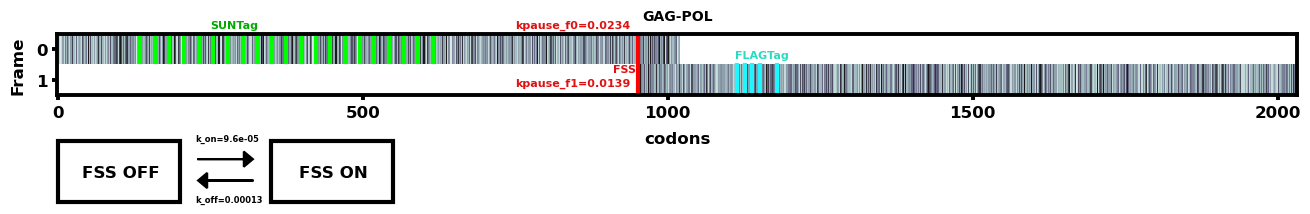

In [ ]:
# Plot construct one
plt.matshow(kelong_mat[:2],aspect=50, cmap='bone_r', alpha=.9)
plt.plot([FSS_LOC,FSS_LOC],[-.5,1.5],'r-',lw=3)
for x in np.where(model_pause_twostate._probe_mat == 1)[1]:
    plt.plot([x,x],[-.5,.4],'-',lw=3, color="#00FF00")
for x in np.where(model_pause_twostate._probe_mat == 2)[1]:
    plt.plot([x,x],[.5, 1.5],'-',lw=3, color="#1DF7FF")

plt.title('GAG-POL')
plt.xlabel('codons')
ax = plt.gca()
ax.xaxis.set_ticks_position('bottom')

plt.text(250, -.7, 'SUNTag', size=8, color="#00AA00")
plt.text(1110, .3, 'FLAGTag', size=8, color="#2BDAC2")

plt.text(910, .75, 'FSS', size=8, color="#E01111")

plt.text(750, -.7, 'kpause_f0=%s'%str(kpause_fss_off), size=8, color="#E01111")
plt.text(750, 1.2, 'kpause_f1=%s'%str(kpause_fss_on), size=8, color="#E01111")

state1 = plt.Rectangle((0, 3), 200, 2,
                     facecolor="w", edgecolor='k', lw=3, alpha=1, clip_on=False)

state2 = plt.Rectangle((350, 3), 200, 2,
                     facecolor="w", edgecolor='k', lw=3, alpha=1, clip_on=False)


arrow1 = patches.FancyArrow(230, 3.6, 90, 0,
                      edgecolor='k', lw=1.5, alpha=1, clip_on=False,
                      head_width=.5, head_length=15, facecolor='k', length_includes_head=True)

arrow2 = patches.FancyArrow(320, 4.3, -90, 0,
                      edgecolor='k', lw=1.5, alpha=1, clip_on=False,
                      head_width=.5, head_length=15, facecolor='k', length_includes_head=True)

ax.add_patch(state1);
ax.add_patch(state2);
ax.add_patch(arrow1);
ax.add_patch(arrow2);
ax.set_ylim([1.5,-.5])

plt.text(40, 4.2, 'FSS OFF', size=12, color='k')
plt.text(395, 4.2, 'FSS ON', size=12, color='k')

plt.text(230+45-50, 3, 'k_on=%s'%str(kon), size=6, color="#000000")
plt.text(230+45-50, 5, 'k_off=%s'%str(koff), size=6, color="#000000")

plt.ylabel('Frame')




In [ ]:
n_model_runs = 50
t = np.linspace(0,25000,int(250000))
model_soln = rsnp.solver.solve_ssa(model_pause_twostate, t, n_traj=n_model_runs, burnin=0, verbose=True, cplus=True)

Using C++.....


Running mRNA simulation...: 100%|██████████| 50/50 [00:56<00:00,  1.14s/it]


In [125]:
def plot_statistics(soln_obj, t=np.linspace(0,20000,20001), representative_traj = 0, t_harr=20000, t_spot=10000, thresholds = [5,5]):
    fig,ax = plt.subplots(2,2, figsize=(12,6), tight_layout=True)

    n_traj = soln_obj.n_traj

    intensities = ax[0,0]
    spots = ax[0,1]
    acc = ax[1,1]
    harr = ax[1,0]

    for i in range(soln_obj.I.shape[-1]):
        means = [500, 20]
        intensities.plot(t, soln_obj.I[:,:,i].T/means[i], alpha=.5, color='gray')
        intensities.plot(t, soln_obj.I[representative_traj,:,i]/means[i], alpha=1, )

    spottypes = [0,0,0,0] #off, color1, color2, both
    for i in range(n_traj):
        if soln_obj.I[i, t_spot, 0] < thresholds[0] and soln_obj.I[i, t_spot, 1] < thresholds[1]:
            spottypes[0] +=1
        if soln_obj.I[i, t_spot, 0] >= thresholds[0] and soln_obj.I[i, t_spot, 1] < thresholds[1]:
            spottypes[1] +=1   
        if soln_obj.I[i, t_spot, 0] < thresholds[0] and soln_obj.I[i, t_spot, 1] >= thresholds[1]:
            spottypes[2] +=1   
        if soln_obj.I[i, t_spot, 0] >= thresholds[0] and soln_obj.I[i, t_spot, 1] >= thresholds[1]:
            spottypes[3] +=1  

    labels = ["off", "SUN", 'FLAG', 'Both']
    spots.bar([0,1,2,3], np.array(spottypes)/n_traj, color=[colors[3], colors[0], colors[1], colors[2]])
    spots.set_xticks([0,1,2,3])
    spots.set_xticklabels(labels)

    for i in range(1):
        m = np.mean(soln_obj.I[:,t_harr:t_harr+5,i])
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i], axis=0)/ m)
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i],axis=0)/m + np.std(soln_obj.I[:,t_harr:,i]/m,axis=0)/np.sqrt(n_traj), linestyle='--', color=colors[0],    )
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i],axis=0)/m - np.std(soln_obj.I[:,t_harr:,i]/m,axis=0)/np.sqrt(n_traj), linestyle='--', color=colors[0],    )

    for i in [1]:
        m = np.mean(soln_obj.I[:,t_harr:t_harr+5,i])
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i], axis=0)/ m, color=colors[1], )
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i],axis=0)/m + np.std(soln_obj.I[:,t_harr:,i]/m,axis=0)/np.sqrt(n_traj), linestyle='--', color=colors[1],    )
        harr.plot(t[t_harr:], np.mean(soln_obj.I[:,t_harr:,i],axis=0)/m - np.std(soln_obj.I[:,t_harr:,i]/m,axis=0)/np.sqrt(n_traj), linestyle='--', color=colors[1],    )

    harr.plot([20000, 20000], [0,6],'k-', lw=2)
    intensities.set_xlabel('time (min)')
    harr.set_xlabel('time (min)')
    acc.set_xlabel('tau (min)')
    
    intensities.set_ylabel('Normalized Intensity')
    harr.set_ylabel('Normalized Intensity')
    acc.set_ylabel('Autocorrelation')
    spots.set_ylabel('Probability')

    plt.show()
        

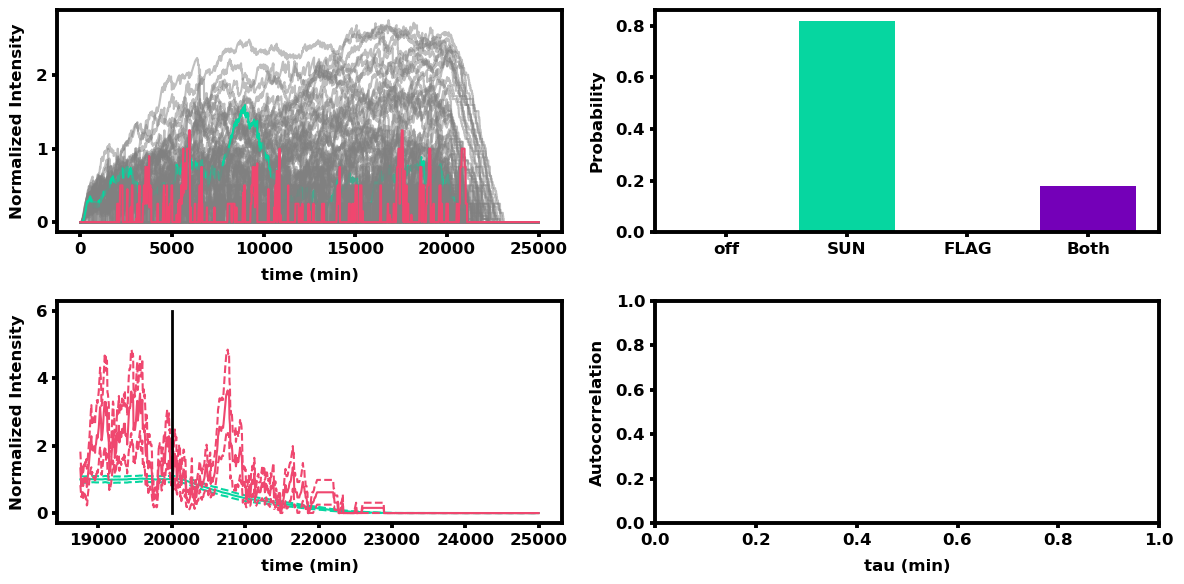

In [126]:
plot_statistics(model_soln, t=t, t_harr=int(15000/5), t_spot=int(10000/5),
                representative_traj = 4,)